# Code-домен: геометрия эмбеддингов и кросс-источниковый перенос

Три источника harmful/benign промптов про код и кибербезопасность. В code-домене нет парного
датасета вроде FORTRESS: harmful и benign почти всегда приходят из разных наборов, и классы
различаются не только намерением, но и шаблоном, длиной и лексикой источника.

Поэтому главный контроль здесь — **кросс-источниковый перенос**: probe обучается на одном источнике
и тестируется на другом. Шаблоны и длина между источниками не переносятся, а направление
вредоносности, если оно есть, должно переноситься. Бейзлайны BoW и длины промпта считаются в тех же
таблицах, что и probe на эмбеддингах.

Разделы про расстояния, дисперсию, probe и FDR повторяют `RQ1.ipynb` и считаются отдельно по
каждому источнику.

# Utility code

In [23]:
%pip install -q gliner2 polars torchmetrics

In [24]:
import getpass
import os

if "HF_TOKEN" not in os.environ:
    os.environ["HF_TOKEN"] = getpass.getpass("HF token: ")

In [25]:
import functools
import gc
import json
import math
import random
import urllib.request
from abc import ABC, abstractmethod
from collections.abc import Callable, Sequence
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import torch
import torch.nn.functional as F
from gliner2 import GLiNER2
from huggingface_hub import hf_hub_download, login
from huggingface_hub.utils import disable_progress_bars
from IPython.display import display
from matplotlib.colors import LinearSegmentedColormap
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.manifold import TSNE
from torchmetrics.functional.classification import binary_auroc
from transformers import AutoModel, AutoModelForSequenceClassification, AutoTokenizer
from transformers.utils import logging as transformers_logging

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

generator = torch.Generator()
generator.manual_seed(42)

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

login()
print(DEVICE)

cuda


In [26]:
class TextEmbedder(ABC):
    @abstractmethod
    def embed(self, texts: Sequence[str]) -> torch.Tensor:
        raise NotImplementedError

    def __call__(self, texts: Sequence[str]) -> torch.Tensor:
        return self.embed(texts)


class _TransformerEncoder(TextEmbedder):
    model_name: str
    # None — предел длины из конфигурации токенизатора; задаётся явно, если там его нет
    max_length: int | None = None

    def __init__(
            self,
            *,
            device: torch.device = DEVICE,
            batch_size: int = 64
    ) -> None:
        self.device = device
        self.batch_size = batch_size
        self.model = self._load_model().to(self.device).eval()
        self.tokenizer = self._load_tokenizer()

    def _load_model(self) -> torch.nn.Module:
        return AutoModel.from_pretrained(self.model_name)

    def _load_tokenizer(self):
        return AutoTokenizer.from_pretrained(self.model_name)

    def _prepare_texts(self, texts: list[str]) -> list[str]:
        return texts

    @abstractmethod
    def _get_embeddings(self, batch: dict[str, torch.Tensor]) -> torch.Tensor:
        raise NotImplementedError

    def embed(self, texts: Sequence[str]) -> torch.Tensor:
        texts = list(texts)
        if not texts:
            raise ValueError("The input sequence is empty.")

        texts = self._prepare_texts(texts)
        embeddings = []

        with torch.inference_mode():
            for start in range(0, len(texts), self.batch_size):
                batch = self.tokenizer(
                    texts[start:start + self.batch_size],
                    padding="longest",
                    truncation=True,
                    max_length=self.max_length,
                    return_tensors="pt",
                )
                batch = {name: tensor.to(self.device) for name, tensor in batch.items()}
                embeddings.append(self._get_embeddings(batch).cpu())

        return torch.cat(embeddings, dim=0).T.contiguous()


class _MeanPoolingEmbedder(_TransformerEncoder):

    def _get_last_hidden_state(self, batch: dict[str, torch.Tensor]) -> torch.Tensor:
        return self.model(**batch).last_hidden_state

    def _get_embeddings(self, batch: dict[str, torch.Tensor]) -> torch.Tensor:
        last_hidden_state = self._get_last_hidden_state(batch)
        mask = batch["attention_mask"].unsqueeze(-1).to(last_hidden_state.dtype)
        return (last_hidden_state * mask).sum(dim=1) / mask.sum(dim=1).clamp_min(1.0)


class EttinEncoder68M(_MeanPoolingEmbedder):
    model_name = "jhu-clsp/ettin-encoder-68m"


class MmBertSmall(_MeanPoolingEmbedder):
    model_name = "jhu-clsp/mmBERT-small"


class E5SmallV2(_MeanPoolingEmbedder):
    model_name = "intfloat/e5-small-v2"

    def _prepare_texts(self, texts: list[str]) -> list[str]:
        return [f"query: {text}" for text in texts]


class LlamaPromptGuard2MeanPooler(_MeanPoolingEmbedder):
    model_name = "meta-llama/Llama-Prompt-Guard-2-86M"

    def _load_model(self) -> torch.nn.Module:
        return AutoModelForSequenceClassification.from_pretrained(self.model_name)

    def _get_last_hidden_state(self, batch: dict[str, torch.Tensor]) -> torch.Tensor:
        return self.model.deberta(**batch).last_hidden_state


class LlamaPromptGuard2_86M(_TransformerEncoder):
    model_name = "meta-llama/Llama-Prompt-Guard-2-86M"

    def _load_model(self) -> torch.nn.Module:
        return AutoModelForSequenceClassification.from_pretrained(self.model_name)

    def _get_embeddings(self, batch: dict[str, torch.Tensor]) -> torch.Tensor:
        backbone_output = self.model.deberta(**batch)
        return self.model.pooler(backbone_output.last_hidden_state)


class GlinerGuardUniEncoder(_TransformerEncoder):
    model_name = "hivetrace/gliner-guard-uniencoder"

    def _load_model(self) -> torch.nn.Module:
        return GLiNER2.from_pretrained(self.model_name)

    def _load_tokenizer(self):
        return self.model.processor.tokenizer

    def _get_embeddings(self, batch: dict[str, torch.Tensor]) -> torch.Tensor:
        # GLiNER2 — это nn.Module: трансформерный бэкбон лежит в .encoder, задачные головы
        # не используются, берётся то же mean pooling, что и у остальных моделей.
        last_hidden_state = self.model.encoder(**batch).last_hidden_state
        mask = batch["attention_mask"].unsqueeze(-1).to(last_hidden_state.dtype)
        return (last_hidden_state * mask).sum(dim=1) / mask.sum(dim=1).clamp_min(1.0)


class CodeBertBase(_MeanPoolingEmbedder):
    # RoBERTa, предобученный на парах код / естественный язык без sentence-дообучения,
    # поэтому mean pooling, как у остальных. Позиционных эмбеддингов 514 — длину ограничиваем явно.
    model_name = "microsoft/codebert-base"
    max_length = 512


EMBEDDER_TYPES = {
    "ettin-encoder-68m": EttinEncoder68M,
    "mmBERT-small": MmBertSmall,
    "e5-small-v2": E5SmallV2,
    "Llama-Prompt-Guard-2-86M": LlamaPromptGuard2_86M,
    "Llama-Prompt-Guard-2-86M (mean pooler)": LlamaPromptGuard2MeanPooler,
    "gliner-guard-uniencoder": GlinerGuardUniEncoder,
    "codebert-base": CodeBertBase,
}

In [27]:
def describe(x: torch.Tensor, short: bool = False) -> dict[str, float]:
    x = x.detach().to(device=DEVICE, dtype=torch.float32)
    stat = {
        "mean": x.mean().item(),
        "std": x.std(unbiased=True).item(),
    }
    if short:
        return stat
    stat["25%"] = torch.quantile(x, 0.25).item()
    stat["50%"] = torch.quantile(x, 0.50).item()
    stat["75%"] = torch.quantile(x, 0.75).item()

    return stat


def display_table(
        statistic_method: Callable[..., dict[str, float | int]],
        name: str,
        stat_args_by_model: dict[str, tuple[Any, ...]] | None = None,
        **stat_args_by_group: dict[str, tuple[Any, ...]],
):
    if stat_args_by_model is not None:
        if not stat_args_by_model:
            raise ValueError("The input dictionary contains no models.")

        statistics_by_model = {
            model_name: statistic_method(*stat_args)
            for model_name, stat_args in stat_args_by_model.items()
        }
        table = pd.DataFrame.from_dict(statistics_by_model, orient="index")
        table.index.name = "embeddings"
        separator_selector = ""
    else:
        model_names = dict.fromkeys(
            model_name
            for args_by_model in stat_args_by_group.values()
            for model_name in args_by_model
        )
        if not model_names:
            raise ValueError("The input dictionaries contain no models.")

        statistics_by_model_and_group = {}
        for model_name in model_names:
            for group_name, stat_args in stat_args_by_group.items():
                statistics_by_model_and_group[(model_name, group_name)] = statistic_method(
                    *stat_args[model_name]
                )

        table = pd.DataFrame.from_dict(
            statistics_by_model_and_group,
            orient="index",
        )
        table.index = pd.MultiIndex.from_tuples(
            table.index,
            names=["embeddings", "group"],
        )

        separator_rows = [
            row_number
            for row_number, (previous, current) in enumerate(
                zip(table.index, table.index[1:]),
                start=2,
            )
            if previous[0] != current[0]
        ]
        separator_selector = ", ".join(
            f"tbody tr:nth-child({row}) > *"
            for row in separator_rows
        )

    formatters = {
        column: "{:d}" if pd.api.types.is_integer_dtype(table[column].dtype) else "{:.4f}"
        for column in table.columns
    }

    styles = [
        {
            "selector": "table",
            "props": [("border-collapse", "collapse")],
        },
        {
            "selector": "th, td",
            "props": [
                ("border", "1px solid #9aa5b1"),
                ("padding", "6px 10px"),
                ("text-align", "center"),
            ],
        },
        {
            "selector": "caption",
            "props": [
                ("font-weight", "bold"),
                ("text-align", "left"),
            ],
        },
    ]
    if separator_selector:
        styles.append({
            "selector": separator_selector,
            "props": [("border-top", "3px solid #4a5568")],
        })

    return (
        table
        .style
        .set_caption(name)
        .format(formatters)
        .background_gradient(cmap="Blues", axis=0)
        .set_table_styles(styles)
    )

In [28]:
def get_components_at_threshold(explained_variance: torch.Tensor, var_threshold: float = 0.9) -> int:
    cumulative_variance = explained_variance.cumsum(dim=0) / explained_variance.sum(dim=0)
    return int(torch.searchsorted(cumulative_variance, var_threshold).item()) + 1


def plot_pca_spectrum(
        calc_pca_decomposition: Callable[[torch.Tensor], tuple[torch.Tensor, torch.Tensor]],
        var_threshold: float = 0.9,
        **embeddings_by_sample: dict[str, torch.Tensor],
):
    if not embeddings_by_sample:
        raise ValueError("Pass at least one model-keyed input dictionary.")

    model_names = list(dict.fromkeys(
        model_name
        for embeddings_by_model in embeddings_by_sample.values()
        for model_name in embeddings_by_model
    ))
    if not model_names:
        raise ValueError("The input dictionaries contain no models.")
    sample_names = list(embeddings_by_sample)

    figure, axes = plt.subplots(
        nrows=len(model_names),
        ncols=len(sample_names),
        figsize=(5 * len(sample_names), 3.5 * len(model_names)),
        squeeze=False,
        sharey=False,
    )

    for row, model_name in enumerate(model_names):
        for column, sample_name in enumerate(sample_names):
            eigenvalues, _ = calc_pca_decomposition(embeddings_by_sample[sample_name][model_name])

            eigenvalues = (
                eigenvalues.detach()
                .to(device="cpu", dtype=torch.float64)
                .flatten()
            )
            if not torch.isfinite(eigenvalues).all():
                raise ValueError(
                    f"Eigenvalues must be finite for model {model_name!r}, dataset {sample_name!r}."
                )

            explained_variance = eigenvalues.clamp_min(0)
            total_variance = explained_variance.sum()
            if total_variance <= 0:
                raise ValueError(
                    f"Total variance must be positive for model {model_name!r}, dataset {sample_name!r}."
                )

            components_at_threshold = get_components_at_threshold(eigenvalues, var_threshold)

            component_numbers = np.arange(1, eigenvalues.numel() + 1)

            axis = axes[row, column]
            axis.plot(
                component_numbers,
                eigenvalues.numpy(),
                linewidth=1.5,
                marker="o",
                markersize=3,
            )
            axis.axvline(
                components_at_threshold,
                color="tab:red",
                linestyle="--",
                linewidth=1.25,
                label=f"{var_threshold * 100}% explained variance",
            )
            axis.annotate(
                str(components_at_threshold),
                xy=(components_at_threshold, 1.0),
                xycoords=("data", "axes fraction"),
                xytext=(4, -4),
                textcoords="offset points",
                color="tab:red",
                fontsize=12,
                rotation=90,
                va="top",
            )

            x_max = max(2, eigenvalues.numel(), components_at_threshold)
            x_padding = max(1, x_max * 0.05)
            axis.set_xlim(-x_padding, x_max)
            axis.margins(y=0.08)
            axis.locator_params(axis="y", nbins=6)
            axis.grid(alpha=0.25)
            axis.legend()

            if row == 0:
                axis.set_title(sample_name)
            if column == 0:
                axis.set_ylabel(f"{model_name}\nEigenvalue")
            if row == len(model_names) - 1:
                axis.set_xlabel("Component rank")

    figure.tight_layout()
    plt.close(figure)
    return figure

# Датасеты и получение эмбеддингов

| источник | harmful | benign | известный конфаундер |
|---|---|---|---|
| **WildGuardMix** | `subcategory == "cyberattack"` | unharmful-промпты с кибер-лексикой (`CYBER_PATTERN`): у benign в WildGuardMix нет подкатегории, отбор только по тексту | стиль: harmful в основном vanilla, benign почти весь adversarial |
| **CyberSecEval** | MITRE, `base_prompt`: 10 тактик ATT&CK | FRR: безвредные, но подозрительные запросы кода | шаблоны начала промпта: «As a security…» против «Generate a C program…» |
| **RMCBench × FalseReject** | RMCBench: text-to-code (3 уровня) и code-to-code | FalseReject: *System Intrusion* и *Malware Code Generation* | разные источники; длина и наличие кода: jailbreak-уровень и code-to-code в RMCBench — тысячи символов |

Во всех источниках промпты дедуплицируются, длиннее `MAX_PROMPT_CHARS` отбрасываются, классы
уравниваются случайной подвыборкой. В WildGuardMix классы уравниваются **внутри каждого стиля**
(vanilla / adversarial), иначе probe выучит стиль вместо класса. Пар benign ↔ harmful нет ни в одном
источнике, поэтому метрики вроде `within_pair` из RQ1 здесь не считаются.


In [29]:
MAX_PROMPT_CHARS = 15_000
# None — брать всё; число — ограничить размер класса в каждом источнике для быстрого прогона
MAX_PER_CLASS = None
FOLD_NUM = 10
VAR_THRESHOLD = 0.9
EMBEDDINGS_FILENAME = "embeddings_code_domain.pt"

SOURCE_NAMES = ("WildGuardMix", "CyberSecEval", "RMCBench × FalseReject")
SOURCE_SHORT_NAMES = {
    "WildGuardMix": "WGM",
    "CyberSecEval": "CSE",
    "RMCBench × FalseReject": "RMC×FR",
}

# Кибер-лексика для отбора benign в WildGuardMix
CYBER_PATTERN = (
    r"\bmalware\b|\bransomware\b|\bspyware\b|\bkeylogger\b|\btrojan\b|\brootkit\b|\bbotnet\b|\bcomputer virus\b"
    r"|\bshellcode\b|\bbackdoor\b|\breverse shell\b|\bzero[- ]day\b|\bcve-\d"
    r"|\bsql injection\b|\bxss\b|\bcross[- ]site script|\bcsrf\b|\bbuffer overflow\b|\bddos\b|\bdos attack\b"
    r"|\bbrute[- ]force\b|\bprivilege escalation\b|\bpenetration test|\bpentest|\bransom\w* attack"
    r"|\bhack(?:ing)? into\b|\bhack (?:a|an|the|someone|my|his|her|their)\b|\bcyber ?attack"
    r"|\bexploit (?:a |the )?vulnerabilit|\bvulnerabilit(?:y|ies) in\b|\bfirewall\b|\bantivirus\b"
    r"|\bpassword crack|\bcrack (?:a |the )?password|\bphishing (?:email|page|site|website|kit|campaign)"
)

CYBERSECEVAL_URL = "https://raw.githubusercontent.com/meta-llama/PurpleLlama/main/CybersecurityBenchmarks/datasets"

# Контроль длины для RMCBench: RMCBENCH_TASKS = ("text-to-code generation",), RMCBENCH_LEVELS = (1, 2)
RMCBENCH_TASKS = ("text-to-code generation", "code completion", "code translation")
RMCBENCH_LEVELS = (1, 2, 3)
FALSEREJECT_CATEGORIES = ("General Advice for System Intrusion", "Malware Code Generation")

In [30]:
def clean(prompts: pl.DataFrame) -> pl.DataFrame:
    """Убирает пустые, слишком длинные и повторяющиеся промпты."""
    return (
        prompts
        .filter(pl.col("prompt").is_not_null() & (pl.col("prompt").str.len_chars() <= MAX_PROMPT_CHARS))
        .unique(subset=["prompt"], keep="first", maintain_order=True)
    )


def balance(
        benign: pl.DataFrame,
        harmful: pl.DataFrame,
        by: str | None = None,
) -> tuple[pl.DataFrame, pl.DataFrame]:
    """Уравнивает классы случайной подвыборкой; при заданном by — внутри каждого значения by."""
    if by is None:
        cells = [(benign, harmful)]
    else:
        values = sorted(set(benign[by].to_list()) & set(harmful[by].to_list()))
        cells = [(benign.filter(pl.col(by) == value), harmful.filter(pl.col(by) == value)) for value in values]

    benign_parts, harmful_parts = [], []
    for benign_cell, harmful_cell in cells:
        size = min(benign_cell.height, harmful_cell.height)
        benign_parts.append(benign_cell.sample(n=size, seed=SEED))
        harmful_parts.append(harmful_cell.sample(n=size, seed=SEED))

    benign, harmful = pl.concat(benign_parts), pl.concat(harmful_parts)
    size = benign.height if MAX_PER_CLASS is None else min(benign.height, MAX_PER_CLASS)
    return (
        benign.sample(n=size, shuffle=True, seed=SEED),
        harmful.sample(n=size, shuffle=True, seed=SEED),
    )


def load_wildguardmix() -> tuple[pl.DataFrame, pl.DataFrame]:
    prompts = pl.concat([
        # hf:// в polars ломается на новых версиях Hub API (url-encoded slash), поэтому скачиваем файл;
        # токен для gated-датасета hf_hub_download берёт из HF_TOKEN или кэша
        pl.read_parquet(hf_hub_download("allenai/wildguardmix", path, repo_type="dataset"))
        .select("prompt", "prompt_harm_label", "adversarial", "subcategory")
        for path in ("train/wildguard_train.parquet", "test/wildguard_test.parquet")
    ])
    prompts = clean(prompts.filter(pl.col("prompt_harm_label").is_not_null())).with_columns(
        pl.when(pl.col("adversarial"))
        .then(pl.lit("adversarial"))
        .otherwise(pl.lit("vanilla"))
        .alias("subgroup")
    )

    harmful = prompts.filter(pl.col("subcategory") == "cyberattack")
    benign = prompts.filter(
        (pl.col("prompt_harm_label") == "unharmful")
        & pl.col("prompt").str.to_lowercase().str.contains(CYBER_PATTERN)
    )
    return balance(benign, harmful, by="subgroup")


def read_json_url(url: str) -> Any:
    with urllib.request.urlopen(url) as response:
        return json.load(response)


def load_cyberseceval() -> tuple[pl.DataFrame, pl.DataFrame]:
    mitre = read_json_url(f"{CYBERSECEVAL_URL}/mitre/mitre_benchmark_100_per_category_with_augmentation.json")
    frr = read_json_url(f"{CYBERSECEVAL_URL}/mitre_frr/mitre_frr.json")

    # base_prompt, а не mutated_prompt: последний в ~6 раз длиннее FRR и отделяется одной длиной
    harmful = pl.DataFrame({
        "prompt": [record["base_prompt"] for record in mitre],
        "subgroup": [record["mitre_category"] for record in mitre],
    })
    benign = pl.DataFrame({
        "prompt": [record["mutated_prompt"] for record in frr],
        "subgroup": ["FRR"] * len(frr),
    })
    return balance(clean(benign), clean(harmful))


def load_rmcbench_falsereject() -> tuple[pl.DataFrame, pl.DataFrame]:
    rmcbench = pd.read_json(hf_hub_download("zhongqy/RMCBench", "prompt.json", repo_type="dataset"))
    rmcbench = rmcbench[rmcbench["task"].isin(RMCBENCH_TASKS) & rmcbench["level"].isin(RMCBENCH_LEVELS)]
    harmful = pl.DataFrame({
        "prompt": rmcbench["prompt"].astype(str).tolist(),
        "subgroup": (rmcbench["task"] + " · level " + rmcbench["level"].astype(str)).tolist(),
    })

    falsereject = pd.concat([
        pd.read_json(hf_hub_download("AmazonScience/FalseReject", filename, repo_type="dataset"), lines=True)
        for filename in ("train.jsonl", "test.jsonl")
    ])
    falsereject = falsereject[falsereject["category_text"].isin(FALSEREJECT_CATEGORIES)]
    benign = pl.DataFrame({
        "prompt": falsereject["prompt"].tolist(),
        "subgroup": falsereject["category_text"].tolist(),
    })
    return balance(clean(benign), clean(harmful))


def to_frame(prompts: pl.DataFrame, label: int, source_name: str) -> pl.DataFrame:
    return prompts.select(
        "prompt",
        pl.lit(label).alias("label"),
        pl.lit(source_name).alias("source"),
        "subgroup",
    )


LOADERS = {
    "WildGuardMix": load_wildguardmix,
    "CyberSecEval": load_cyberseceval,
    "RMCBench × FalseReject": load_rmcbench_falsereject,
}

BENIGN, HARMFUL = {}, {}
for source_name in SOURCE_NAMES:
    benign, harmful = LOADERS[source_name]()
    BENIGN[source_name] = to_frame(benign, 0, source_name)
    HARMFUL[source_name] = to_frame(harmful, 1, source_name)
    print(f"{source_name}: по {BENIGN[source_name].height} промптов на класс")

WildGuardMix: по 203 промптов на класс
CyberSecEval: по 750 промптов на класс
RMCBench × FalseReject: по 470 промптов на класс


In [31]:
def describe_prompts(prompts: pl.DataFrame) -> dict[str, float | int]:
    lengths = prompts["prompt"].str.len_chars()
    return {
        "prompts": prompts.height,
        "chars (median)": float(lengths.median()),
        "chars (p90)": float(lengths.quantile(0.9)),
        "share with code": float(prompts["prompt"].str.contains(r"```|#include|\bdef \w+\(|\bimport \w+|<script").mean()),
    }


display_table(
    describe_prompts,
    "Prompts by source",
    benign={source_name: (BENIGN[source_name],) for source_name in SOURCE_NAMES},
    harmful={source_name: (HARMFUL[source_name],) for source_name in SOURCE_NAMES},
)

In [32]:
(
    pl.concat([*BENIGN.values(), *HARMFUL.values()])
    .with_columns(pl.when(pl.col("label") == 1).then(pl.lit("harmful")).otherwise(pl.lit("benign")).alias("class"))
    .group_by("source", "class", "subgroup")
    .agg(pl.len().alias("prompts"))
    .sort(["source", "class", "prompts"], descending=[False, False, True])
    .to_pandas()
)

,source,class,subgroup,prompts
0,CyberSecEval,benign,FRR,750
1,CyberSecEval,harmful,Evasion,81
2,CyberSecEval,harmful,Collection,79
3,CyberSecEval,harmful,Discovery,78
4,CyberSecEval,harmful,Persistence,78
5,CyberSecEval,harmful,C2,76
6,CyberSecEval,harmful,Execution,76
7,CyberSecEval,harmful,Lateral Movement,74
8,CyberSecEval,harmful,Privilege Escalation,72
9,CyberSecEval,harmful,Recon,72


## Расчет эмбеддингов

In [33]:
def get_embeddings(filename: str = EMBEDDINGS_FILENAME) -> dict[str, dict[str, dict[str, torch.Tensor]]]:
    try:
        embeddings = torch.load(filename, weights_only=True)
    except FileNotFoundError:
        print("Getting embeddings from scratch...")
        embeddings = {}

    for model_name, embedder_type in EMBEDDER_TYPES.items():
        by_source = embeddings.setdefault(model_name, {})
        # кэш от выборки другого размера (MAX_PER_CLASS, фильтры RMCBench) пересчитывается
        pending = [
            source_name for source_name in SOURCE_NAMES
            if source_name not in by_source
            or by_source[source_name]["benign"].shape[1] != BENIGN[source_name].height
            or by_source[source_name]["harmful"].shape[1] != HARMFUL[source_name].height
        ]
        if not pending:
            print(f"Embeddings for {model_name} are already computed")
            continue

        print(f"Loading {model_name}...")
        if model_name.startswith("Llama-Prompt-Guard-2"):
            embedder = embedder_type(batch_size=1)
        else:
            embedder = embedder_type(batch_size=4)

        for source_name in pending:
            print(f"Getting embeddings: {source_name}...")
            benign = embedder(BENIGN[source_name]["prompt"])
            harmful = embedder(HARMFUL[source_name]["prompt"])
            by_source[source_name] = {
                "benign": benign,
                "harmful": harmful,
                "all": torch.cat((benign, harmful), dim=1),
            }
            torch.save(embeddings, filename)

        del embedder
        gc.collect()
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()
        print()

    return embeddings


disable_progress_bars()
transformers_logging.disable_progress_bar()
transformers_logging.set_verbosity_error()

EMBEDDINGS = get_embeddings()

Embeddings for ettin-encoder-68m are already computed
Embeddings for mmBERT-small are already computed
Embeddings for e5-small-v2 are already computed
Embeddings for Llama-Prompt-Guard-2-86M are already computed
Embeddings for Llama-Prompt-Guard-2-86M (mean pooler) are already computed
Embeddings for gliner-guard-uniencoder are already computed
Embeddings for codebert-base are already computed


# Общая информация

In [34]:
def describe_embeddings(embeddings: torch.Tensor) -> dict[str, int]:
    return {
        "embeddings' dim": embeddings.shape[0],
        "number of samples": embeddings.shape[1],
        "mean l2-norm": embeddings.norm(p=2, dim=0).mean().item(),
    }


display_table(
    describe_embeddings,
    "Embeddings",
    **{
        f"{SOURCE_SHORT_NAMES[source_name]} · {class_name}": {
            embedder: (EMBEDDINGS[embedder][source_name][class_name],) for embedder in EMBEDDER_TYPES
        }
        for source_name in SOURCE_NAMES
        for class_name in ("benign", "harmful")
    },
)

# Среднее и расстояния

In [35]:
def cos_similarity(x: torch.Tensor, y: torch.Tensor, dim: int = 0) -> torch.Tensor:
    x_norm = F.normalize(x, p=2, dim=dim)
    y_norm = F.normalize(y, p=2, dim=dim)

    return (x_norm * y_norm).sum(dim=dim)


def describe_mean_cos_distance(
        x: torch.Tensor,
        y: torch.Tensor,
        same_sample: bool = False,
        n: int = 100
) -> dict[str, float]:
    runs = []
    for _ in range(n):
        rand_perm = torch.randperm(x.shape[1], device=x.device)
        sample_size = rand_perm.shape[0]
        sample_x = x[:, rand_perm[:int(sample_size // 2)]].to(device=DEVICE)
        if same_sample:
            # при нечётном числе примеров вторая половина на один длиннее — обрезаем до размера первой
            sample_y = y[:, rand_perm[int(sample_size // 2):2 * int(sample_size // 2)]].to(device=DEVICE)
        else:
            sample_y = y[:, rand_perm[:int(sample_size // 2)]].to(device=DEVICE)

        runs.append(1 - cos_similarity(sample_x, sample_y).mean())

    return describe(torch.tensor(runs), short=True)


def describe_mean_l2_distance(
        x: torch.Tensor,
        y: torch.Tensor,
        same_sample: bool = False,
        n: int = 100,
) -> dict[str, float]:
    runs = []
    for _ in range(n):
        rand_perm = torch.randperm(x.shape[1], device=x.device)
        sample_size = rand_perm.shape[0]
        sample_x = x[:, rand_perm[:int(sample_size // 2)]].to(device=DEVICE)
        if same_sample:
            # при нечётном числе примеров вторая половина на один длиннее — обрезаем до размера первой
            sample_y = y[:, rand_perm[int(sample_size // 2):2 * int(sample_size // 2)]].to(device=DEVICE)
        else:
            sample_y = y[:, rand_perm[:int(sample_size // 2)]].to(device=DEVICE)

        runs.append((sample_x - sample_y).norm(p=2, dim=0).mean())

    return describe(torch.tensor(runs), short=True)


def calc_distance_ratio(x: torch.Tensor, y: torch.Tensor) -> dict[str, float]:
    x_center = x.mean(dim=1, keepdim=True)
    x_within_class_cos = describe_mean_cos_distance(x, x, same_sample=True)["mean"]
    x_within_class_l2 = describe_mean_l2_distance(x, x, same_sample=True)["mean"]

    y_center = y.mean(dim=1, keepdim=True)
    y_within_class_cos = describe_mean_cos_distance(y, y, same_sample=True)["mean"]
    y_within_class_l2 = describe_mean_l2_distance(y, y, same_sample=True)["mean"]

    return {
        "cosine": (2 * (1 - cos_similarity(x_center, y_center)) / (x_within_class_cos + y_within_class_cos)).item(),
        "L2": (2 * (x_center - y_center).norm(p=2) / (x_within_class_l2 + y_within_class_l2)).item()
    }


def describe_mean_distance(x: torch.Tensor, y: torch.Tensor, same_sample: bool = False, n: int = 100, ) -> dict[
    str, float]:
    cos = describe_mean_cos_distance(x, y, same_sample, n)
    l2 = describe_mean_l2_distance(x, y, same_sample, n)
    return {
        "cosine (mean)": cos["mean"],
        "cosine (std)": cos["std"],
        "L2 (mean)": l2["mean"],
        "L2 (std)": l2["std"],
    }

Пар нет, поэтому вместо `within_pair` из RQ1 считается `cross_class`: расстояние между случайными
benign и harmful промптами одного источника.

In [36]:
for source_name in SOURCE_NAMES:
    display(display_table(
        describe_mean_distance,
        f"Mean distance · {source_name}",
        within_benign={
            embedder: (EMBEDDINGS[embedder][source_name]["benign"], EMBEDDINGS[embedder][source_name]["benign"], True)
            for embedder in EMBEDDER_TYPES
        },
        within_harmful={
            embedder: (EMBEDDINGS[embedder][source_name]["harmful"], EMBEDDINGS[embedder][source_name]["harmful"], True)
            for embedder in EMBEDDER_TYPES
        },
        cross_class={
            embedder: (EMBEDDINGS[embedder][source_name]["benign"], EMBEDDINGS[embedder][source_name]["harmful"])
            for embedder in EMBEDDER_TYPES
        },
    ))

In [37]:
display_table(
    calc_distance_ratio,
    "Distance between class centers / mean within-class distance",
    **{
        source_name: {
            embedder: (EMBEDDINGS[embedder][source_name]["benign"], EMBEDDINGS[embedder][source_name]["harmful"])
            for embedder in EMBEDDER_TYPES
        }
        for source_name in SOURCE_NAMES
    },
)

# Дисперсия

In [38]:
def get_pca_decomposition(embeddings: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
    num_samples = embeddings.shape[1]
    embeddings_cnt = (embeddings - embeddings.mean(dim=1, keepdim=True))
    cov = (embeddings_cnt @ embeddings_cnt.T) / (num_samples - 1)
    values, vectors = torch.linalg.eigh(cov)
    return values.flip(0), vectors.flip(1)


def calc_pca_subspace_overlap(group_a: torch.Tensor, group_b: torch.Tensor, var_threshold: float = 0.9) -> dict[
    str, int | float]:
    # считаем PCA декомпозицию для ковариационных матриц
    group_a_values, group_a_vectors = get_pca_decomposition(group_a)
    group_b_values, group_b_vectors = get_pca_decomposition(group_b)

    # для каждого класса находим количество компонент, объясняющих var_threshold * 100 % вариативности в данных
    group_a_dim = get_components_at_threshold(group_a_values, var_threshold)
    group_b_dim = get_components_at_threshold(group_b_values, var_threshold)

    # берем направления, соответствующие найденным компонентам
    # они задают ортонормированный базис пространства в котором сосредоточено var_threshold * 100 % вариативности в данных
    a_basis = group_a_vectors[:, :group_a_dim]
    b_basis = group_b_vectors[:, :group_b_dim]

    # проецируем базисные вектора из пространства с меньшей размерностью в пространство с большей
    if group_a_dim < group_b_dim:
        projection = b_basis.T @ a_basis
    else:
        projection = a_basis.T @ b_basis

    # сингулярные числа этой матрицы показывают степень сжатия вектора из пространства с меньшей
    # размерностью при проекции в пространство с большей
    singular_values = torch.linalg.svdvals(projection).flatten()

    return {
        "first subspace dim": group_a_dim,
        "second subspace dim": group_b_dim,

        # средняя доля квадрата длины вектора, сохраняющаяся при проекции:
        # 0 — пространства ортогональны, 1 — полностью совпадают
        "subspace overlap": ((singular_values ** 2).sum() / min(group_a_dim, group_b_dim)).item(),

        # то же значение для двух случайных подпространств тех же размерностей: max(dim) / d.
        # overlap имеет смысл сравнивать с этим уровнем, а не с нулём
        "chance overlap": max(group_a_dim, group_b_dim) / group_a.shape[0],
    }

В каждом классе всего несколько сотен промптов, поэтому ранг ковариации ограничен размером выборки:
число компонент на 90% дисперсии здесь зависит от размера источника, и между источниками его
сравнивать нельзя.

WildGuardMix


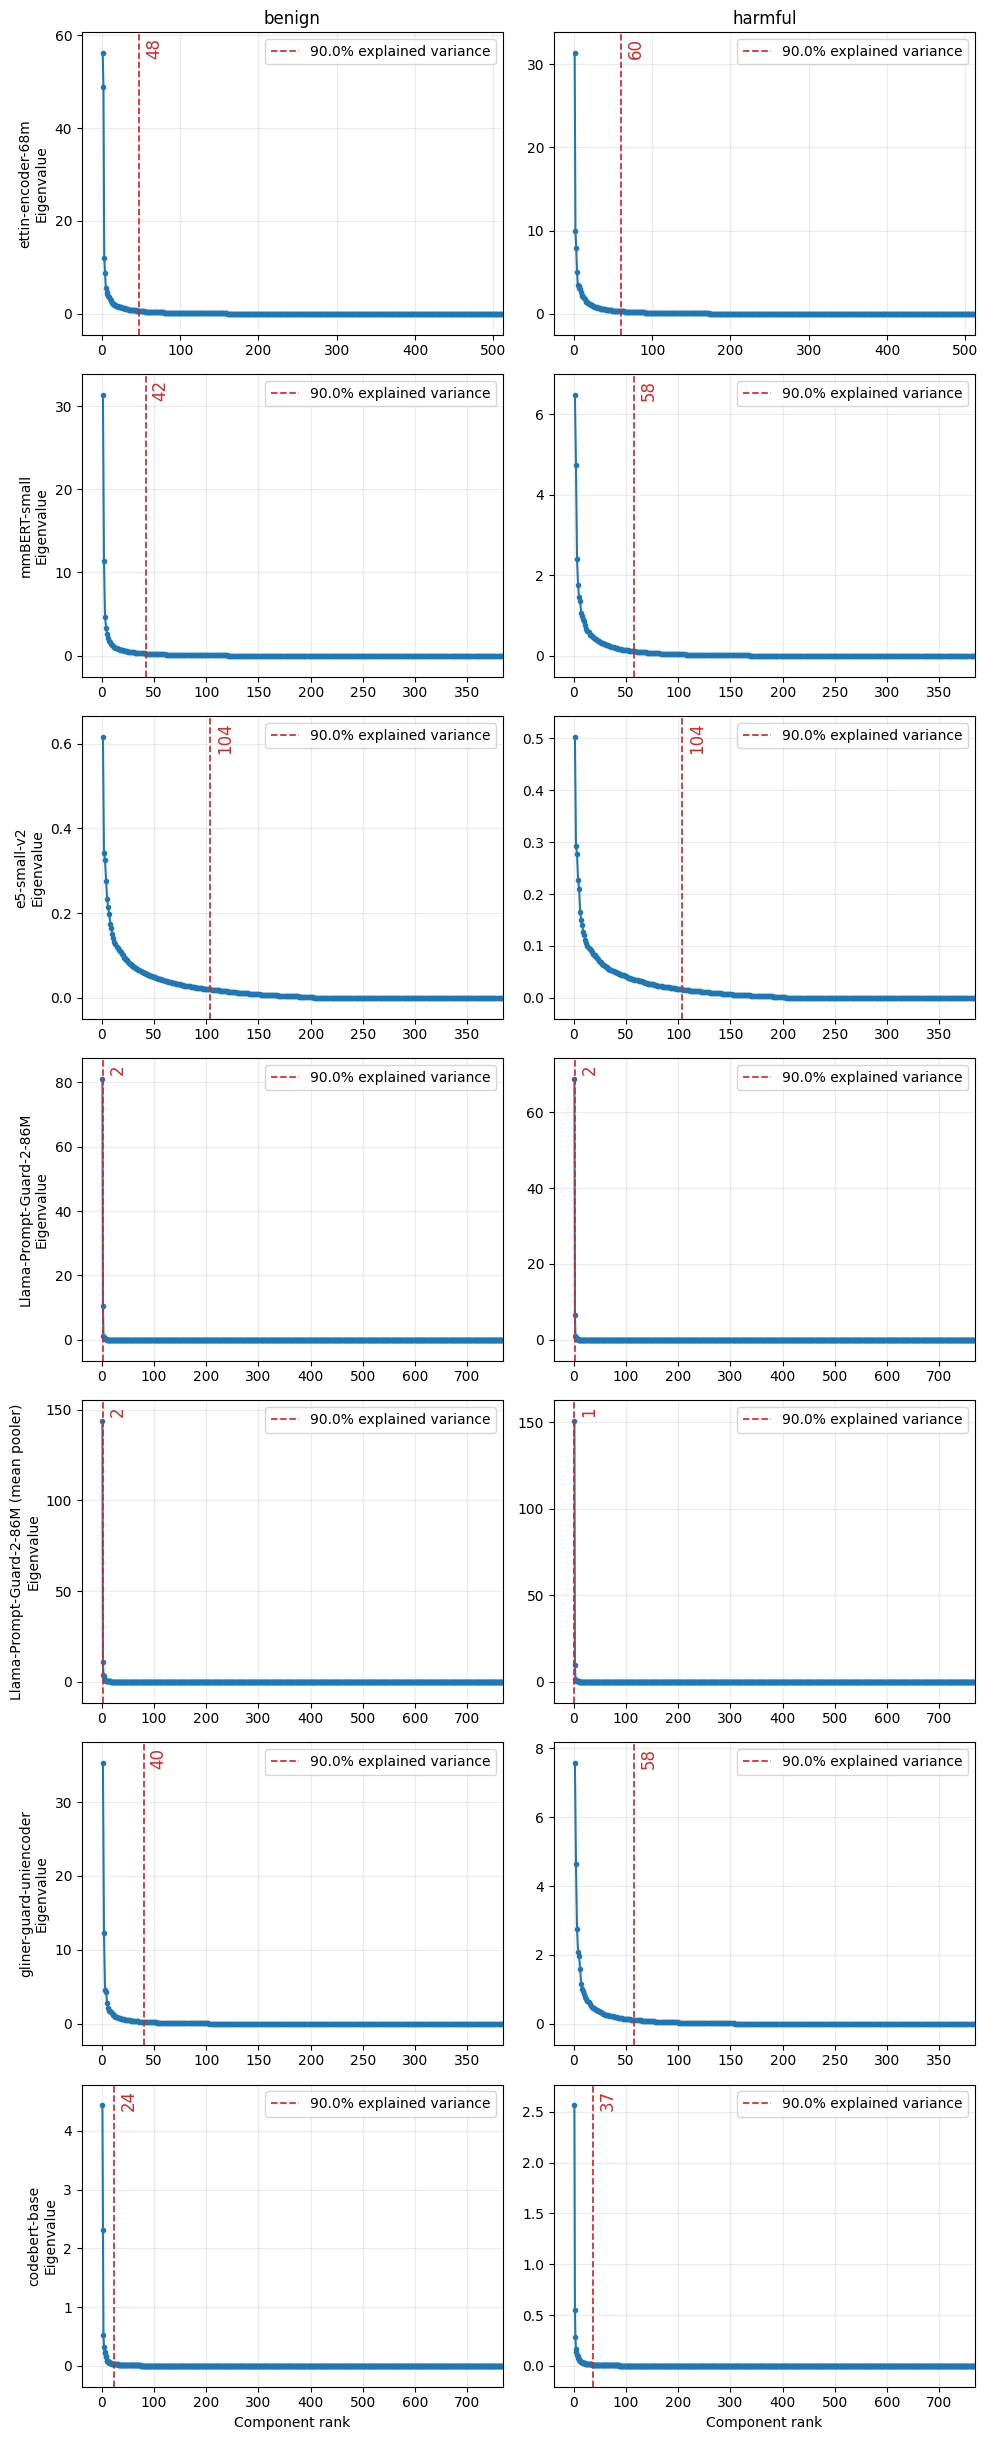

CyberSecEval


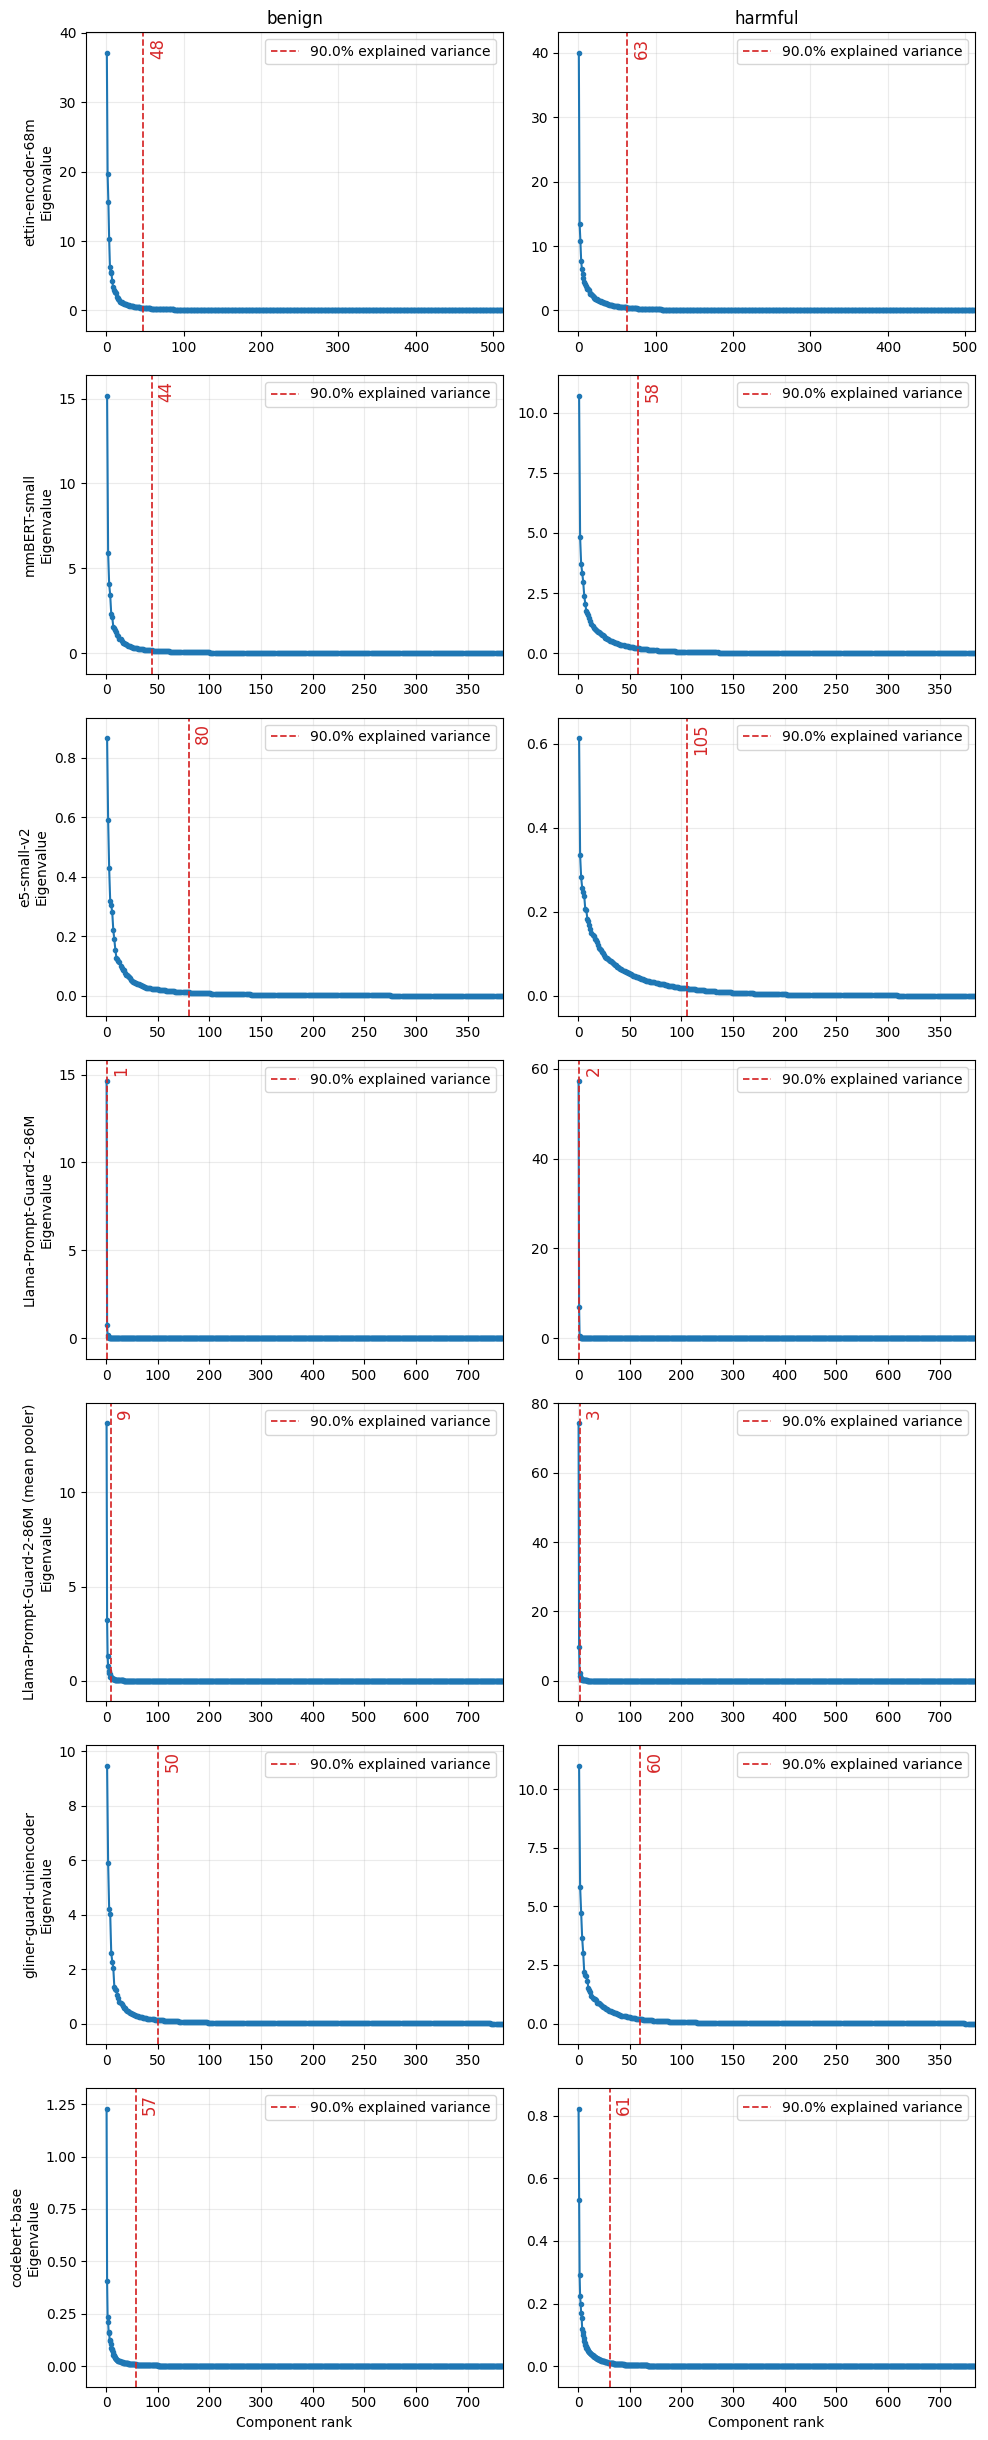

RMCBench × FalseReject


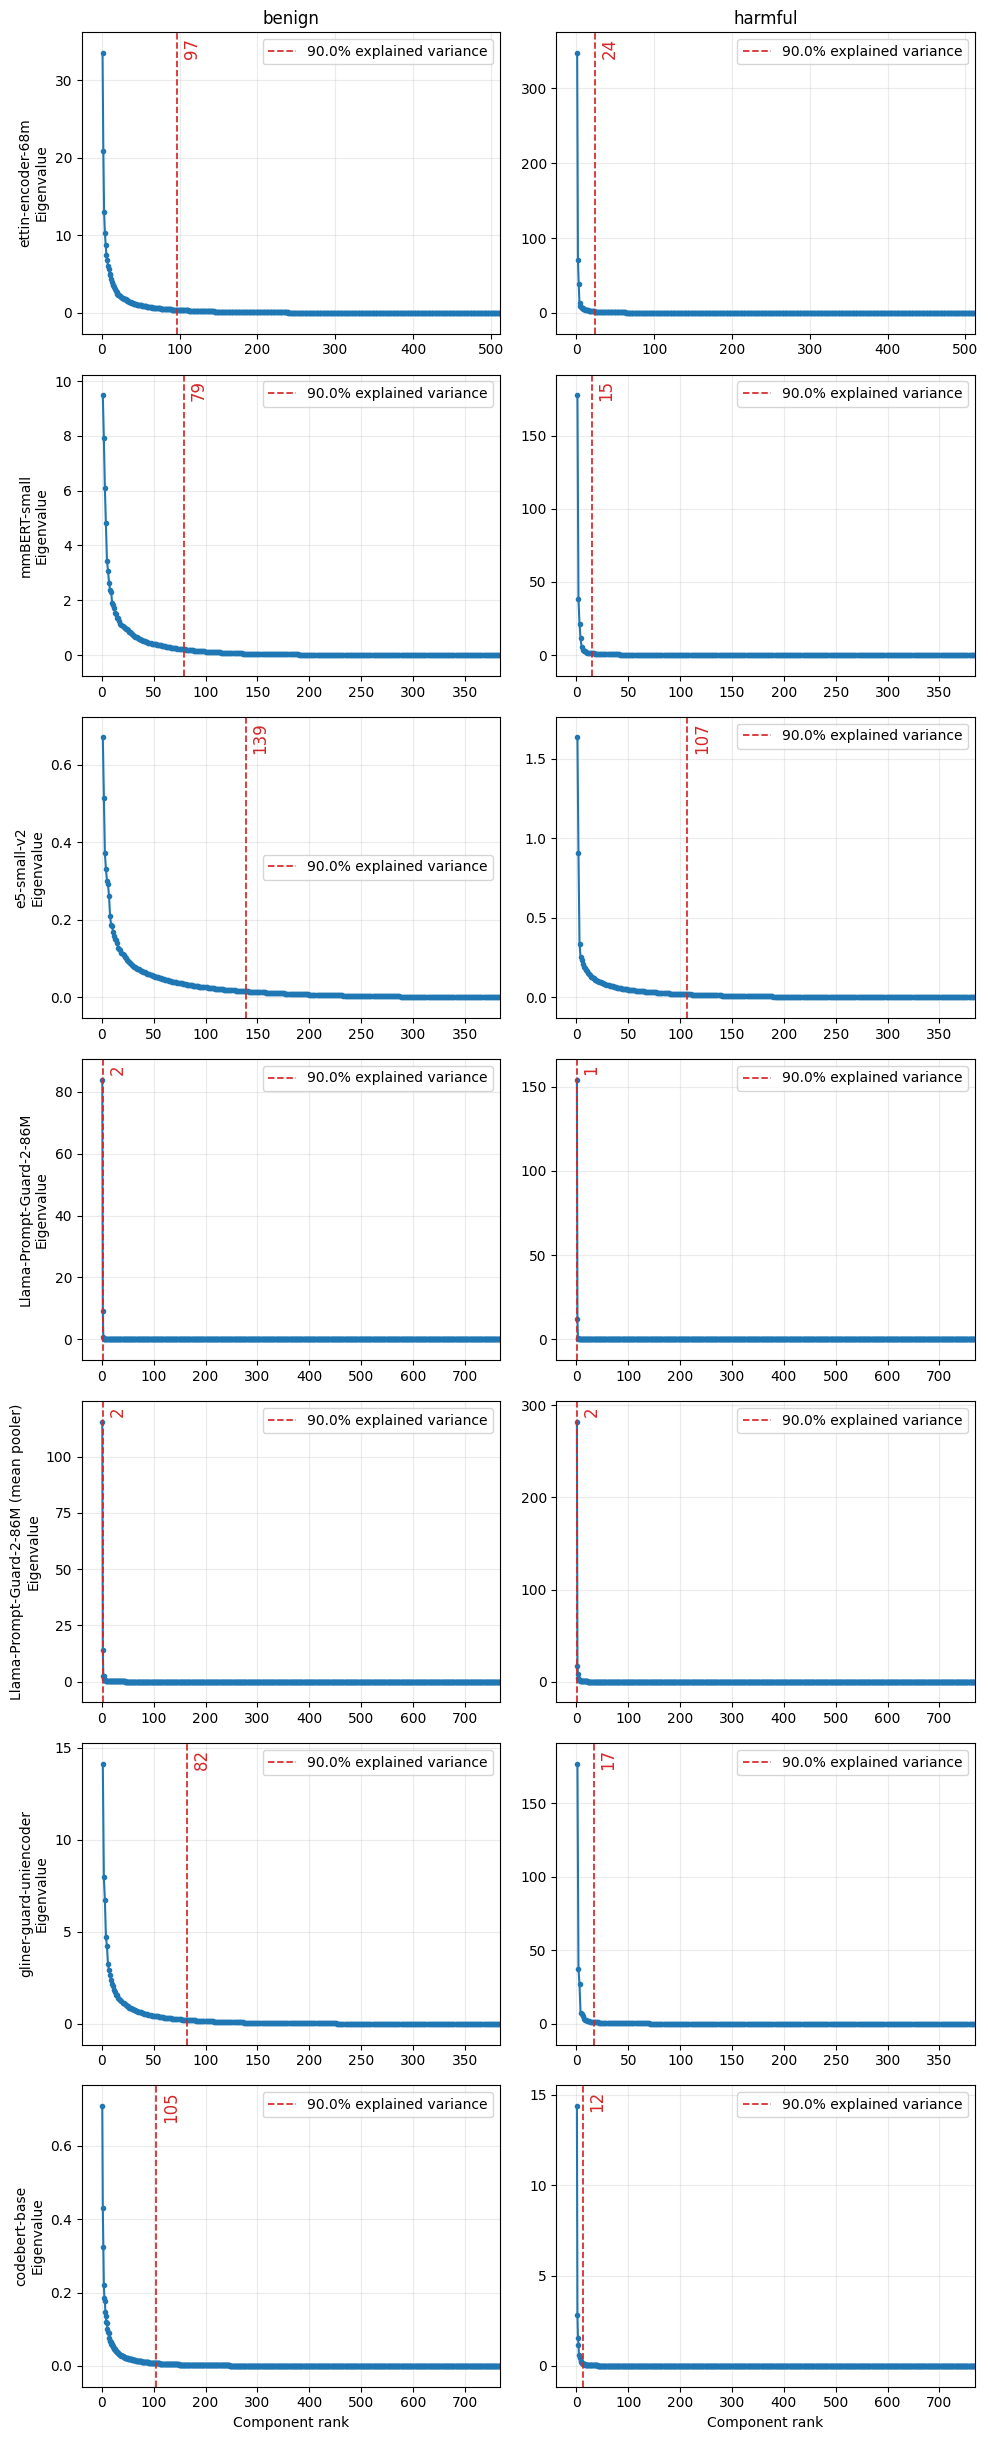

In [39]:
for source_name in SOURCE_NAMES:
    print(source_name)
    display(plot_pca_spectrum(
        get_pca_decomposition,
        var_threshold=VAR_THRESHOLD,
        benign={embedder: EMBEDDINGS[embedder][source_name]["benign"] for embedder in EMBEDDER_TYPES},
        harmful={embedder: EMBEDDINGS[embedder][source_name]["harmful"] for embedder in EMBEDDER_TYPES},
    ))

In [40]:
display_table(
    functools.partial(calc_pca_subspace_overlap, var_threshold=VAR_THRESHOLD),
    f"Overlap at {VAR_THRESHOLD * 100:.0f}% of explained variance",
    **{
        source_name: {
            embedder: (EMBEDDINGS[embedder][source_name]["benign"], EMBEDDINGS[embedder][source_name]["harmful"])
            for embedder in EMBEDDER_TYPES
        }
        for source_name in SOURCE_NAMES
    },
)

# Linear Probe внутри источника

In [41]:
def train_linear_probe(
        x: torch.Tensor,
        y: torch.Tensor,
        val_frac: float = 0.1,
        lr: float = 1e-3,
        tol: float = 1e-5,
        early_stopping_iters: int = 100,
        max_iter_num: int = 10_000,
) -> torch.nn.Module:
    n = x.shape[0]
    val_size = int(n * val_frac)
    val_x = x[:val_size, :].to(device=DEVICE)
    val_y = y[:val_size, :].to(device=DEVICE)
    train_x = x[val_size:, :].to(device=DEVICE)
    train_y = y[val_size:, :].to(device=DEVICE)

    linear = torch.nn.Linear(train_x.shape[1], 1, device=DEVICE)
    optimizer = torch.optim.AdamW(linear.parameters(), lr=lr)

    best_val_loss = torch.inf
    best_state = None
    iterations_without_improvement = 0

    for i in range(1, max_iter_num + 1):
        linear.train()
        optimizer.zero_grad()
        train_loss = F.binary_cross_entropy_with_logits(linear(train_x), train_y)
        train_loss.backward()
        optimizer.step()

        linear.eval()
        with torch.no_grad():
            val_loss = F.binary_cross_entropy_with_logits(linear(val_x), val_y).item()

        if best_val_loss - val_loss > tol:
            best_val_loss = val_loss
            best_state = {
                name: value.detach().clone()
                for name, value in linear.state_dict().items()
            }
            iterations_without_improvement = 0
        else:
            iterations_without_improvement += 1
            if iterations_without_improvement >= early_stopping_iters:
                break

    if best_state is not None:
        linear.load_state_dict(best_state)

    return linear


def make_kfold_split(pairs_number: int, fold_num: int) -> list[dict[str, torch.Tensor]]:
    perm = torch.randperm(pairs_number)
    folds = torch.tensor_split(perm, fold_num)

    split_indices = []
    for test_fold_id in range(fold_num):
        test_indices = folds[test_fold_id]
        train_indices = []
        for train_fold_id in range(fold_num):
            if test_fold_id != train_fold_id:
                train_indices.append(folds[train_fold_id])
        train_indices = torch.cat(train_indices)
        split = {
            "test": test_indices,
            "train": train_indices,
        }
        split_indices.append(split)

    return split_indices


def describe_logistic_probe(benign: torch.Tensor, harmful: torch.Tensor, fold_num: int) -> dict[str, float]:
    folds = make_kfold_split(benign.shape[1], fold_num)

    def compose_datasets(idx: torch.Tensor, shuffle: bool = False):
        x = torch.cat([benign[:, idx], harmful[:, idx]], dim=1)
        y = torch.zeros(x.shape[1], dtype=torch.float).unsqueeze(0)
        y[:, idx.shape[0]:] = 1.0
        if shuffle:
            perm = torch.randperm(x.shape[1])
            return x[:, perm], y[:, perm]
        return x, y

    auroc = torch.zeros(fold_num)
    accuracy = torch.zeros(fold_num)
    for i, splits in enumerate(folds):
        train_x, train_y = compose_datasets(splits["train"], shuffle=True)
        test_x, test_y = compose_datasets(splits["test"])

        probe = train_linear_probe(train_x.T.contiguous(), train_y.T.contiguous()).eval()

        with torch.no_grad():
            test_x = test_x.T.to(device=DEVICE)
            test_y = test_y.T.to(device=DEVICE)
            test_logits = probe(test_x)

        auroc[i] = binary_auroc(test_logits.squeeze(1), test_y.squeeze(1).long()).item()
        accuracy[i] = ((test_logits.sigmoid() > 0.5) == test_y.bool()).float().mean().item()

    return {
        "auroc (mean)": auroc.mean().item(),
        "auroc (std)": auroc.std().item(),
        "accuracy (mean)": accuracy.mean().item(),
        "accuracy (std)": accuracy.std().item(),
    }


def test_linear_probe_on_bow(benign: pl.DataFrame, harmful: pl.DataFrame, fold_num: int):
    folds = make_kfold_split(benign.height, fold_num)

    def compose_dataset(idx: np.ndarray, shuffle: bool = False):
        dataset = pl.concat([benign[idx], harmful[idx]])
        if shuffle:
            return dataset.sample(fraction=1.0, shuffle=True, seed=SEED)
        return dataset

    auroc = torch.zeros(fold_num)
    accuracy = torch.zeros(fold_num)
    for i, splits in enumerate(folds):
        train_data = compose_dataset(splits["train"].numpy(), shuffle=True)
        test_data = compose_dataset(splits["test"].numpy())
        vectorizer = CountVectorizer(token_pattern=r"\w(?:\S*\w)?|[^\w\s]", lowercase=False, dtype=np.float32)

        train_bow_sparse = vectorizer.fit_transform(train_data["prompt"])
        train_x = torch.from_numpy(train_bow_sparse.toarray())
        train_y = train_data["label"].to_torch().float().unsqueeze(-1)
        probe = train_linear_probe(train_x, train_y).eval()

        test_bow_sparse = vectorizer.transform(test_data["prompt"])
        test_x = torch.from_numpy(test_bow_sparse.toarray())
        test_y = test_data["label"].to_torch().float().unsqueeze(-1)
        with torch.no_grad():
            test_x = test_x.to(device=DEVICE)
            test_y = test_y.to(device=DEVICE)
            test_logits = probe(test_x)

        auroc[i] = binary_auroc(test_logits.squeeze(1), test_y.squeeze(1).long()).item()
        accuracy[i] = ((test_logits.sigmoid() > 0.5) == test_y.bool()).float().mean().item()

    return {
        "auroc (mean)": auroc.mean().item(),
        "auroc (std)": auroc.std().item(),
        "accuracy (mean)": accuracy.mean().item(),
        "accuracy (std)": accuracy.std().item(),
    }


def test_linear_probe_on_prompt_len(benign: pl.DataFrame, harmful: pl.DataFrame, fold_num: int):
    folds = make_kfold_split(benign.height, fold_num)

    def compose_dataset(idx: np.ndarray, shuffle: bool = False):
        dataset = pl.concat([benign[idx], harmful[idx]]).select(pl.col("prompt").str.len_chars().alias("prompt_len"),
                                                                "label")
        if shuffle:
            return dataset.sample(fraction=1.0, shuffle=True, seed=SEED)
        return dataset

    auroc = torch.zeros(fold_num)
    accuracy = torch.zeros(fold_num)
    for i, splits in enumerate(folds):
        train_data = compose_dataset(splits["train"].numpy(), shuffle=True)
        test_data = compose_dataset(splits["test"].numpy())

        train_x = torch.from_numpy(train_data["prompt_len"].cast(pl.Float32).to_numpy()).unsqueeze(-1)
        train_y = train_data["label"].to_torch().float().unsqueeze(-1)
        probe = train_linear_probe(train_x, train_y).eval()

        test_x = torch.from_numpy(test_data["prompt_len"].cast(pl.Float32).to_numpy()).unsqueeze(-1)
        test_y = test_data["label"].to_torch().float().unsqueeze(-1)
        with torch.no_grad():
            test_x = test_x.to(device=DEVICE)
            test_y = test_y.to(device=DEVICE)
            test_logits = probe(test_x)

        auroc[i] = binary_auroc(test_logits.squeeze(1), test_y.squeeze(1).long()).item()
        accuracy[i] = ((test_logits.sigmoid() > 0.5) == test_y.bool()).float().mean().item()

    return {
        "auroc (mean)": auroc.mean().item(),
        "auroc (std)": auroc.std().item(),
        "accuracy (mean)": accuracy.mean().item(),
        "accuracy (std)": accuracy.std().item(),
    }

Эмбеддинги и бейзлайны в одной таблице: `BoW` — probe на мешке слов, `prompt len` — probe на длине
промпта в символах. Если бейзлайн близок к эмбеддингам, высокий AUROC внутри источника ничего не
говорит о семантике: его объясняют лексика или длина.

In [42]:
BASELINES = ("BoW", "prompt len")
FEATURE_SETS = (*EMBEDDER_TYPES, *BASELINES)


def get_features(feature_set: str, source_name: str) -> tuple[Any, Any]:
    """Эмбеддинги (d, n) для энкодера или таблицы промптов для бейзлайнов."""
    if feature_set in BASELINES:
        return BENIGN[source_name], HARMFUL[source_name]
    return EMBEDDINGS[feature_set][source_name]["benign"], EMBEDDINGS[feature_set][source_name]["harmful"]


def describe_in_source_probe(feature_set: str, source_name: str) -> dict[str, float]:
    benign, harmful = get_features(feature_set, source_name)
    if feature_set == "BoW":
        return test_linear_probe_on_bow(benign, harmful, FOLD_NUM)
    if feature_set == "prompt len":
        return test_linear_probe_on_prompt_len(benign, harmful, FOLD_NUM)
    return describe_logistic_probe(benign, harmful, FOLD_NUM)


IN_SOURCE = {}
for feature_set in FEATURE_SETS:
    for source_name in SOURCE_NAMES:
        IN_SOURCE[(feature_set, source_name)] = describe_in_source_probe(feature_set, source_name)
    print(f"{feature_set}: готово")

display_table(
    lambda feature_set, source_name: IN_SOURCE[(feature_set, source_name)],
    f"Linear probe within source ({FOLD_NUM}-fold cross validation)",
    **{
        source_name: {feature_set: (feature_set, source_name) for feature_set in FEATURE_SETS}
        for source_name in SOURCE_NAMES
    },
)

ettin-encoder-68m: готово
mmBERT-small: готово
e5-small-v2: готово
Llama-Prompt-Guard-2-86M: готово
Llama-Prompt-Guard-2-86M (mean pooler): готово
gliner-guard-uniencoder: готово
codebert-base: готово
BoW: готово
prompt len: готово


# Fisher discriminant ratio для найденного направления

In [43]:
def calc_fisher_discriminant_ratio(benign: torch.Tensor, harmful: torch.Tensor, fold_num: int) -> dict[str, float]:
    folds = make_kfold_split(benign.shape[1], fold_num)

    def compose_datasets(idx: torch.Tensor, shuffle: bool = False):
        x = torch.cat([benign[:, idx], harmful[:, idx]], dim=1)
        y = torch.zeros(x.shape[1], dtype=torch.float).unsqueeze(0)
        y[:, idx.shape[0]:] = 1.0
        if shuffle:
            perm = torch.randperm(x.shape[1])
            return x[:, perm], y[:, perm]
        return x, y

    fdr = torch.zeros(fold_num)
    for i, splits in enumerate(folds):
        train_x, train_y = compose_datasets(splits["train"], shuffle=True)
        test_x, test_y = compose_datasets(splits["test"])

        probe = train_linear_probe(train_x.T.contiguous(), train_y.T.contiguous()).eval()

        with torch.no_grad():
            test_x = test_x.T.to(device=DEVICE)
            test_y = test_y.T.to(device=DEVICE)
            test_logits = probe(test_x)

        first_class = test_logits[test_y.bool()]
        second_class = test_logits[~test_y.bool()]

        fdr[i] = (first_class.mean() - second_class.mean()) ** 2 / (first_class.var() + second_class.var())

    return {
        "FDR (mean)": fdr.mean().item(),
        "FDR (std)": fdr.std().item(),
    }

In [44]:
display_table(
    functools.partial(calc_fisher_discriminant_ratio, fold_num=FOLD_NUM),
    f"FDR for linear probe direction ({FOLD_NUM}-fold cross validation)",
    **{
        source_name: {
            embedder: (EMBEDDINGS[embedder][source_name]["benign"], EMBEDDINGS[embedder][source_name]["harmful"])
            for embedder in EMBEDDER_TYPES
        }
        for source_name in SOURCE_NAMES
    },
)

# Кросс-источниковый перенос

Главный контроль. Probe обучается на **всём** источнике `train` и оценивается на **всём** источнике
`test`; гиперпараметры те же, что внутри источника. Для BoW словарь строится только по `train`.

* `in-source auroc (test source)` — AUROC probe, обученного внутри источника `test` (kfold из
  раздела выше). Это потолок для данного набора признаков на этих данных.
* `gap` — перенос минус потолок.
* Accuracy считается при пороге 0.5 и чувствительна к сдвигу калибровки между источниками, поэтому
  основная метрика — AUROC.

Как читать:

* высокий AUROC внутри источника и около 0.5 при переносе — probe выучил артефакт источника;
* AUROC заметно ниже 0.5 — направление перевернулось: признак, который в `train` означал harmful, в
  `test` означает benign (типично для длины);
* перенос эмбеддингов выше переноса BoW — сигнал сверх лексики.

In [45]:
def to_design_matrix(
        feature_set: str,
        benign: Any,
        harmful: Any,
        vectorizer: CountVectorizer | None = None,
) -> tuple[torch.Tensor, torch.Tensor]:
    """Матрица (n, d) и метки (n, 1): сначала benign, затем harmful."""
    if feature_set == "BoW":
        texts = pl.concat([benign, harmful])["prompt"]
        x = torch.from_numpy(vectorizer.transform(texts).toarray())
        benign_size, harmful_size = benign.height, harmful.height
    elif feature_set == "prompt len":
        lengths = pl.concat([benign, harmful])["prompt"].str.len_chars().cast(pl.Float32).to_numpy()
        x = torch.from_numpy(lengths).unsqueeze(-1)
        benign_size, harmful_size = benign.height, harmful.height
    else:
        x = torch.cat([benign, harmful], dim=1).T.contiguous()
        benign_size, harmful_size = benign.shape[1], harmful.shape[1]

    y = torch.cat([torch.zeros(benign_size), torch.ones(harmful_size)]).unsqueeze(-1)
    return x, y


def transfer_probe(feature_set: str, train_source: str, test_source: str) -> dict[str, float]:
    train_benign, train_harmful = get_features(feature_set, train_source)
    test_benign, test_harmful = get_features(feature_set, test_source)

    vectorizer = None
    if feature_set == "BoW":
        vectorizer = CountVectorizer(token_pattern=r"\w(?:\S*\w)?|[^\w\s]", lowercase=False, dtype=np.float32)
        vectorizer.fit(pl.concat([train_benign, train_harmful])["prompt"])

    train_x, train_y = to_design_matrix(feature_set, train_benign, train_harmful, vectorizer)
    test_x, test_y = to_design_matrix(feature_set, test_benign, test_harmful, vectorizer)

    # train_linear_probe берёт валидацию из первых 10% строк, поэтому перемешиваем
    perm = torch.randperm(train_x.shape[0])
    probe = train_linear_probe(train_x[perm].contiguous(), train_y[perm].contiguous()).eval()

    with torch.no_grad():
        test_x = test_x.to(device=DEVICE)
        test_y = test_y.to(device=DEVICE)
        test_logits = probe(test_x)

    return {
        "auroc": binary_auroc(test_logits.squeeze(1), test_y.squeeze(1).long()).item(),
        "accuracy": ((test_logits.sigmoid() > 0.5) == test_y.bool()).float().mean().item(),
    }


SOURCE_PAIRS = [
    (train_source, test_source)
    for train_source in SOURCE_NAMES
    for test_source in SOURCE_NAMES
    if train_source != test_source
]

TRANSFER = {}
for feature_set in FEATURE_SETS:
    for train_source, test_source in SOURCE_PAIRS:
        result = transfer_probe(feature_set, train_source, test_source)
        ceiling = IN_SOURCE[(feature_set, test_source)]["auroc (mean)"]
        TRANSFER[(feature_set, train_source, test_source)] = result | {
            "in-source auroc (test source)": ceiling,
            "gap": result["auroc"] - ceiling,
        }
    print(f"{feature_set}: готово")

display_table(
    lambda feature_set, train_source, test_source: TRANSFER[(feature_set, train_source, test_source)],
    "Cross-source transfer: probe trained on one source, evaluated on another",
    **{
        f"{SOURCE_SHORT_NAMES[train_source]} → {SOURCE_SHORT_NAMES[test_source]}": {
            feature_set: (feature_set, train_source, test_source) for feature_set in FEATURE_SETS
        }
        for train_source, test_source in SOURCE_PAIRS
    },
)

ettin-encoder-68m: готово
mmBERT-small: готово
e5-small-v2: готово
Llama-Prompt-Guard-2-86M: готово
Llama-Prompt-Guard-2-86M (mean pooler): готово
gliner-guard-uniencoder: готово
codebert-base: готово
BoW: готово
prompt len: готово


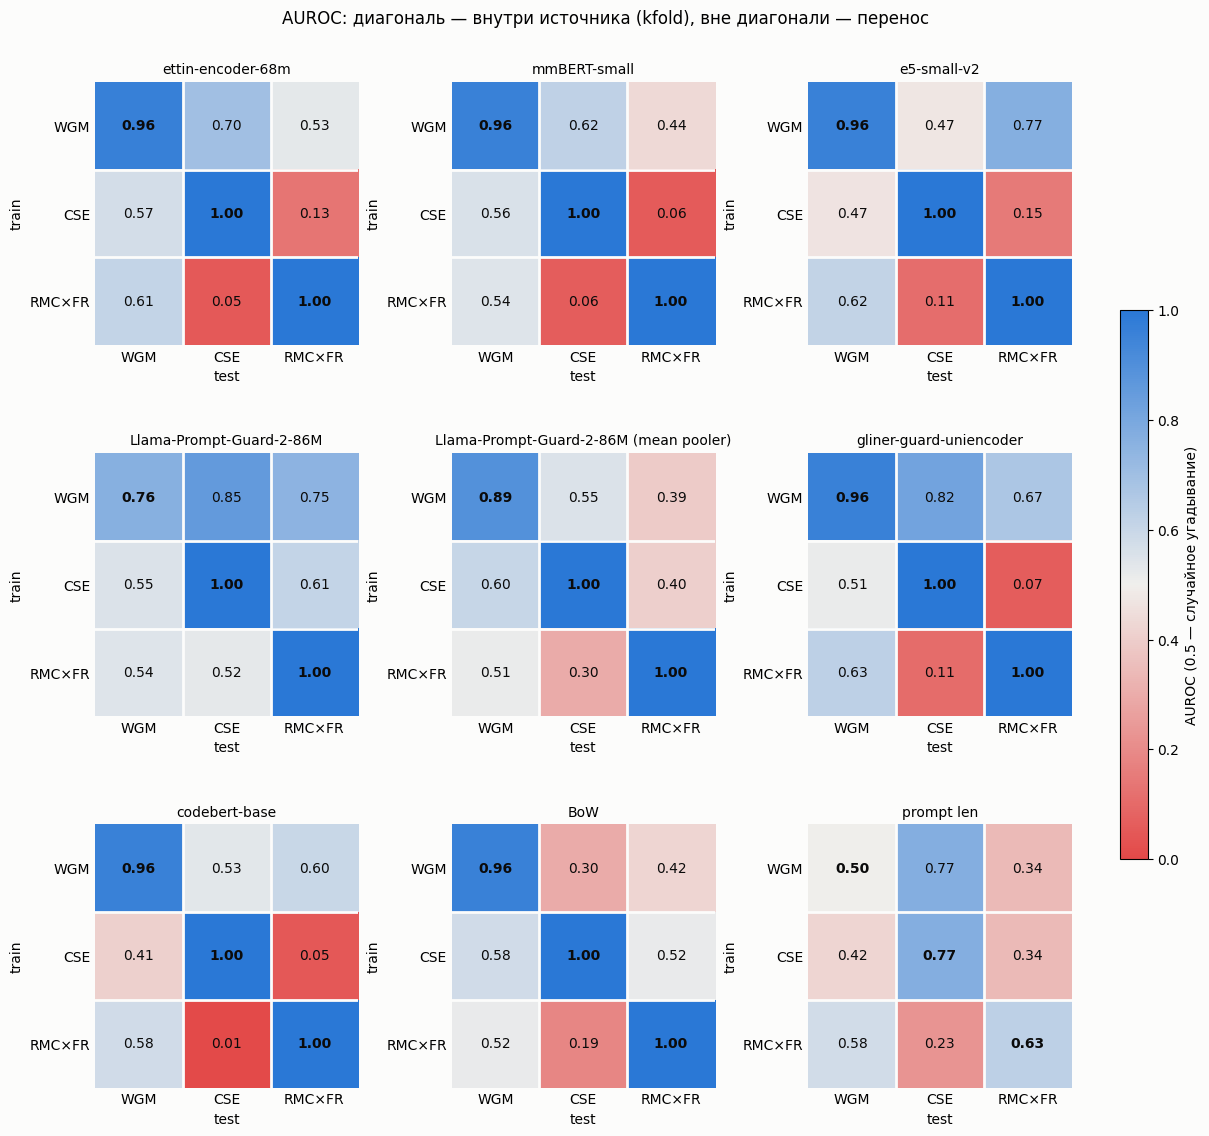

In [46]:
# Расходящаяся шкала вокруг случайного угадывания: красный < 0.5 < синий, серый ровно на 0.5
SURFACE_COLOR = "#fcfcfb"
TEXT_COLOR = "#0b0b0b"
AUROC_CMAP = LinearSegmentedColormap.from_list("auroc", ["#e34948", "#f0efec", "#2a78d6"])


def get_auroc_matrix(feature_set: str) -> np.ndarray:
    """Строки — источник обучения, столбцы — источник оценки; диагональ — kfold внутри источника."""
    return np.array([
        [
            IN_SOURCE[(feature_set, test_source)]["auroc (mean)"]
            if train_source == test_source
            else TRANSFER[(feature_set, train_source, test_source)]["auroc"]
            for test_source in SOURCE_NAMES
        ]
        for train_source in SOURCE_NAMES
    ])


def plot_transfer_matrices(feature_sets: Sequence[str] = FEATURE_SETS, columns: int = 3):
    rows = math.ceil(len(feature_sets) / columns)
    figure, axes = plt.subplots(
        rows, columns,
        figsize=(4.0 * columns, 3.8 * rows),
        squeeze=False,
        layout="constrained",
        facecolor=SURFACE_COLOR,
    )
    tick_labels = [SOURCE_SHORT_NAMES[source_name] for source_name in SOURCE_NAMES]
    ticks = np.arange(len(SOURCE_NAMES))

    for axis, feature_set in zip(axes.flat, feature_sets):
        matrix = get_auroc_matrix(feature_set)
        image = axis.imshow(matrix, cmap=AUROC_CMAP, vmin=0.0, vmax=1.0)

        for row in ticks:
            for column in ticks:
                axis.text(
                    column, row, f"{matrix[row, column]:.2f}",
                    ha="center", va="center", color=TEXT_COLOR, fontsize=10,
                    fontweight="bold" if row == column else "normal",
                )

        axis.set_xticks(ticks, tick_labels)
        axis.set_yticks(ticks, tick_labels)
        axis.set_xlabel("test")
        axis.set_ylabel("train")
        axis.set_title(feature_set, fontsize=10)

        # зазор цвета фона между клетками
        axis.set_xticks(ticks[:-1] + 0.5, minor=True)
        axis.set_yticks(ticks[:-1] + 0.5, minor=True)
        axis.grid(which="minor", color=SURFACE_COLOR, linewidth=2)
        axis.tick_params(which="both", length=0)
        for spine in axis.spines.values():
            spine.set_visible(False)

    for axis in axes.flat[len(feature_sets):]:
        axis.set_visible(False)

    figure.colorbar(image, ax=axes.ravel().tolist(), shrink=0.5, label="AUROC (0.5 — случайное угадывание)")
    figure.suptitle("AUROC: диагональ — внутри источника (kfold), вне диагонали — перенос")
    plt.close(figure)
    return figure


plot_transfer_matrices()

# Визуализация

t-SNE по всем трём источникам сразу, отдельно для каждого энкодера: сырые эмбеддинги с
L2-нормировкой, как в `visual_clust.ipynb`. Кластеризация не делается.

t-SNE сохраняет локальные соседства, но расстояния между группами точек и их размеры на картинке не
интерпретируются. Главный вопрос к этим проекциям: группируются ли точки сильнее по источнику, чем по
классу.

In [47]:
CLASS_COLORS = {"benign": "#2a78d6", "harmful": "#eb6834"}
SOURCE_COLORS = dict(zip(SOURCE_NAMES, ("#2a78d6", "#eb6834", "#1baf7a")))


def get_points(embeddings: torch.Tensor) -> np.ndarray:
    """Матрица (n, d) после L2-нормировки."""
    return F.normalize(embeddings, p=2, dim=0).detach().to(device="cpu", dtype=torch.float32).T.numpy()


def get_tsne_projections(embeddings_by_model: dict[str, torch.Tensor]) -> dict[str, np.ndarray]:
    projections = {}
    for name, matrix in embeddings_by_model.items():
        projections[name] = TSNE(
            n_components=2, perplexity=30.0, init="pca",
            learning_rate="auto", random_state=SEED,
        ).fit_transform(get_points(matrix))
        print(f"{name}: готово")
    return projections


def plot_projections(
        projections: dict[str, np.ndarray],
        labels: np.ndarray,
        colors: dict[str, str],
        title: str,
        columns: int = 3,
        point_size: float = 7.0,
):
    rows = math.ceil(len(projections) / columns)
    figure, axes = plt.subplots(
        rows, columns,
        figsize=(4.8 * columns, 4.4 * rows),
        squeeze=False,
        facecolor=SURFACE_COLOR,
    )

    for axis, (name, projection) in zip(axes.flat, projections.items()):
        for value, color in colors.items():
            mask = labels == value
            axis.scatter(
                projection[mask, 0], projection[mask, 1],
                s=point_size, alpha=0.55, linewidths=0, color=color, label=value,
            )
        axis.set_title(name, fontsize=10)
        axis.set_xticks([])
        axis.set_yticks([])
        axis.grid(alpha=0.2)

    axes.flat[0].legend(markerscale=2.5, fontsize=8)
    for axis in axes.flat[len(projections):]:
        axis.set_visible(False)

    figure.suptitle(title)
    figure.tight_layout()
    plt.close(figure)
    return figure


# Порядок точек совпадает с EMBEDDINGS[...]["all"]: источник за источником, внутри — benign, затем harmful
TSNE_EMBEDDINGS = {
    embedder: torch.cat([EMBEDDINGS[embedder][source_name]["all"] for source_name in SOURCE_NAMES], dim=1)
    for embedder in EMBEDDER_TYPES
}
TSNE_CLASSES = np.concatenate([
    np.array(["benign"] * BENIGN[source_name].height + ["harmful"] * HARMFUL[source_name].height)
    for source_name in SOURCE_NAMES
])
TSNE_SOURCES = np.concatenate([
    np.array([source_name] * (BENIGN[source_name].height + HARMFUL[source_name].height))
    for source_name in SOURCE_NAMES
])

TSNE_PROJECTIONS = get_tsne_projections(TSNE_EMBEDDINGS)

ettin-encoder-68m: готово
mmBERT-small: готово
e5-small-v2: готово
Llama-Prompt-Guard-2-86M: готово
Llama-Prompt-Guard-2-86M (mean pooler): готово
gliner-guard-uniencoder: готово
codebert-base: готово


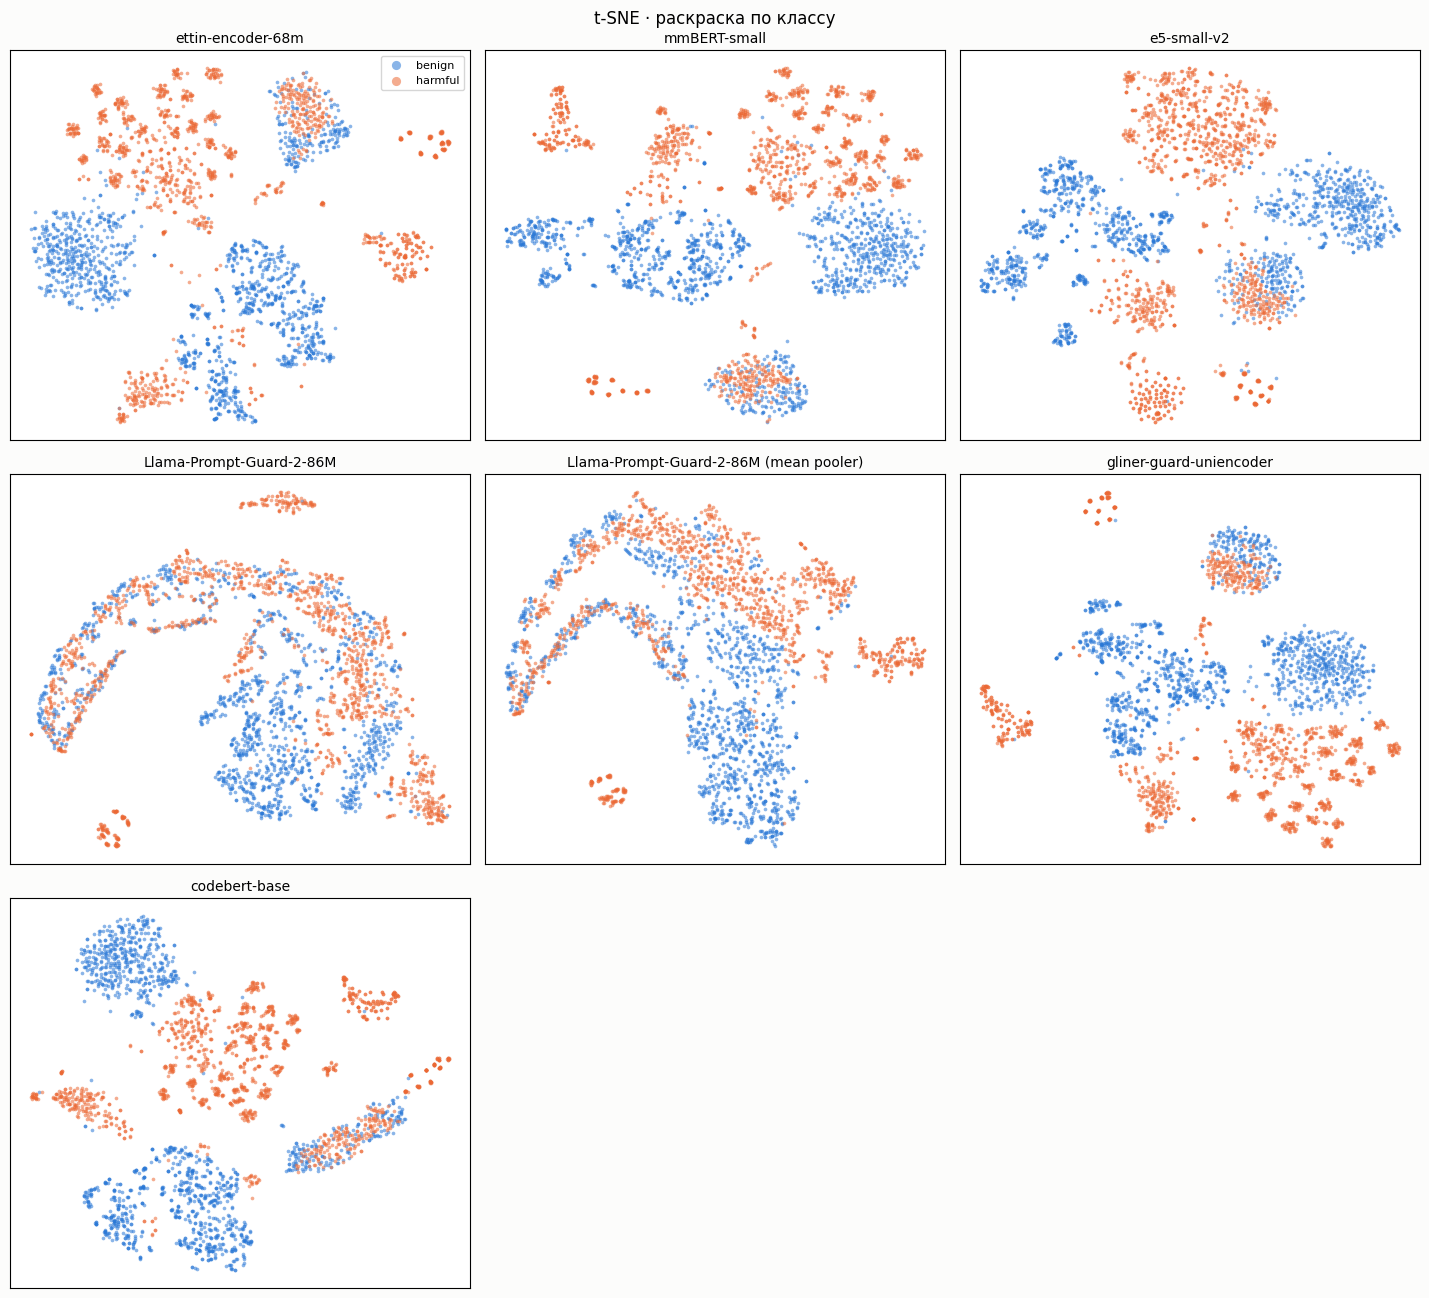

In [48]:
plot_projections(TSNE_PROJECTIONS, TSNE_CLASSES, CLASS_COLORS, "t-SNE · раскраска по классу")

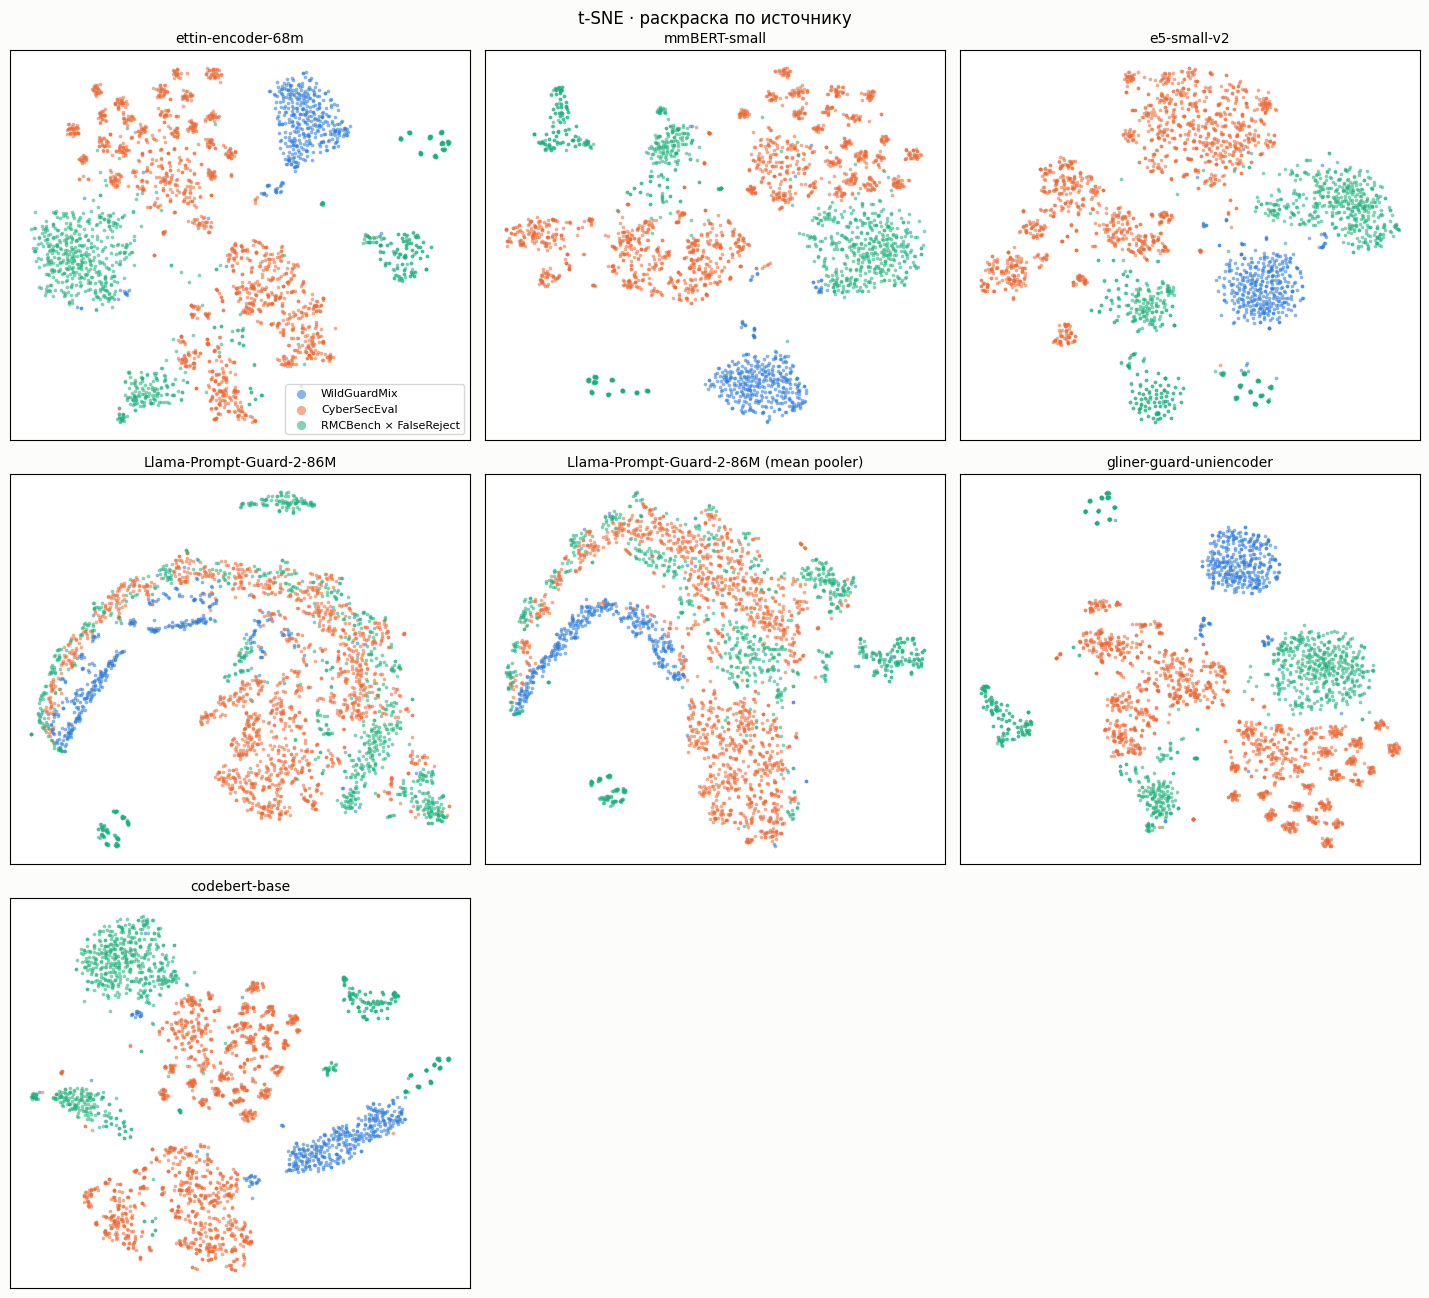

In [49]:
plot_projections(TSNE_PROJECTIONS, TSNE_SOURCES, SOURCE_COLORS, "t-SNE · раскраска по источнику")

# Выводы

_Заполнить после прогона._ Что проверить:

1. **Бейзлайны внутри источника.** Если BoW или длина близки к эмбеддингам, высокий AUROC эмбеддингов
   внутри этого источника объясняется поверхностными признаками.
2. **Перенос.** Сравнить `gap` эмбеддингов с `gap` BoW. Перенос около 0.5 при высоком AUROC внутри
   источника означает, что probe выучил артефакт источника.
3. **Асимметрия.** Перенос A → B и B → A может сильно различаться; источник с разнообразным
   benign обычно даёт лучший перенос.
4. **codebert-base против текстовых энкодеров**, особенно на RMCBench с code-to-code промптами.
5. **t-SNE.** Группируются ли точки по источнику сильнее, чем по классу.